In [1]:
import pandas as pd
from sklearn.impute import SimpleImputer

In [2]:
df=pd.read_csv("loan_approval_data.csv")
df_num=df.select_dtypes(include=["float64"]).columns
df_cat=df.select_dtypes(include=["str"]).columns
print(df_num)
print(df_cat)
df.head()

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='str')
Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='str')


,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [3]:
num_imp=SimpleImputer(strategy="mean")
df[df_num]=num_imp.fit_transform(df[df_num])
cat_imp=SimpleImputer(strategy="most_frequent")
df[df_cat]=cat_imp.fit_transform(df[df_cat])

Loan_Approved
No     702
Yes    298
Name: count, dtype: int64


Text(0.5, 1.0, 'Loan_Approval')

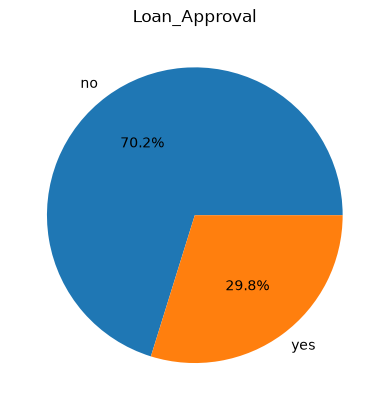

In [4]:
data=df["Loan_Approved"].value_counts()
print(data)
import matplotlib.pyplot as plt
plt.pie(data,labels=["no","yes"],autopct="%1.1f%%")
plt.title("Loan_Approval")

Gender
Male      621
Female    379
Name: count, dtype: int64


<Axes: xlabel='Gender', ylabel='count'>

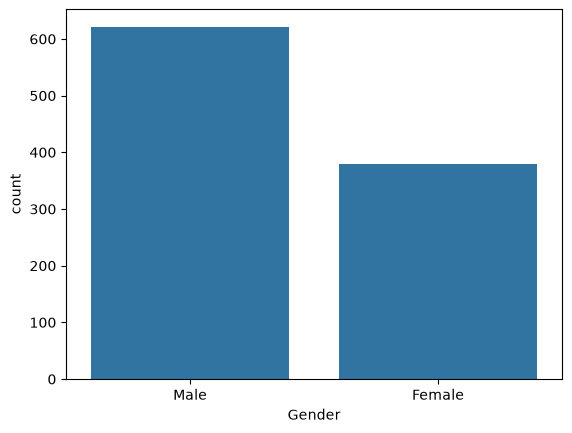

In [5]:
#gender value 
import seaborn as sns
data=df["Gender"].value_counts()
print(data)
sns.barplot(data)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

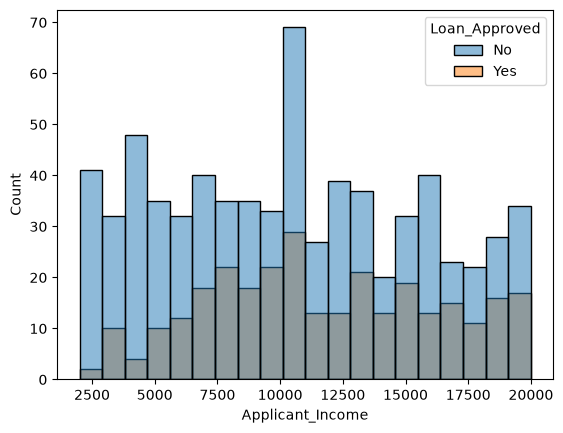

In [6]:
sns.histplot(data=df,x="Applicant_Income",hue="Loan_Approved",bins=20)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

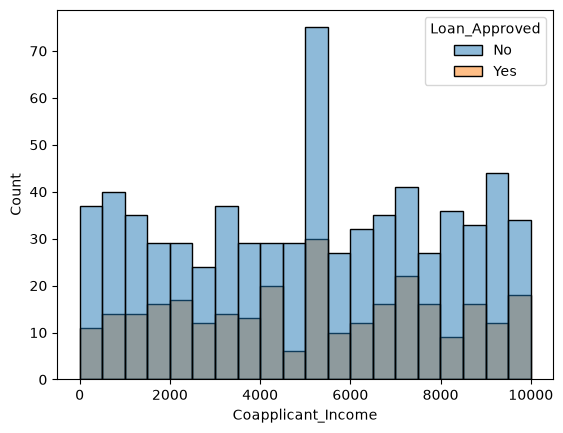

In [7]:
sns.histplot(data=df,x="Coapplicant_Income",hue="Loan_Approved",bins=20)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

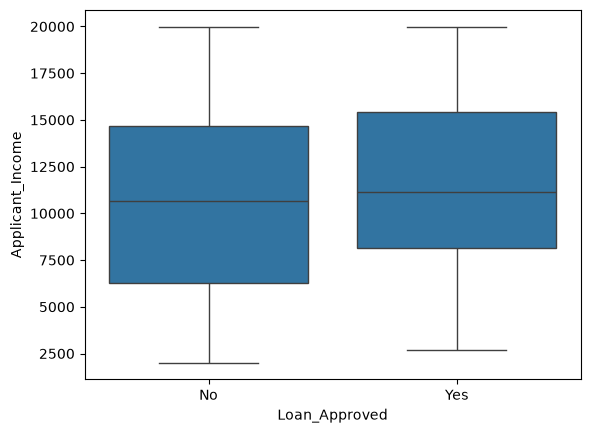

In [8]:
sns.boxplot(data=df,y="Applicant_Income",x="Loan_Approved")

<Axes: xlabel='Loan_Approved', ylabel='Credit_Score'>

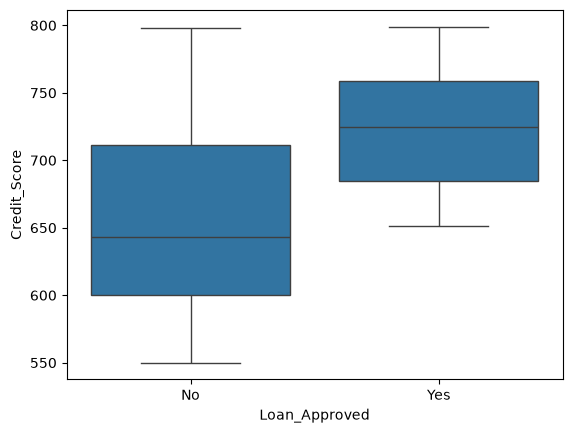

In [9]:
sns.boxplot(data=df,y="Credit_Score",x="Loan_Approved")

In [10]:
#removing applicant id
df=df.drop("Applicant_ID",axis=1)

In [11]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [13]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
le=LabelEncoder()
df["Marital_Status"]=le.fit_transform(df["Marital_Status"])
df["Education_Level"]=le.fit_transform(df["Education_Level"])
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])

In [18]:
cols=["Loan_Purpose","Property_Area","Employment_Status","Gender","Employer_Category"]
ohe=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
df1=ohe.fit_transform(df[cols])
df1

array([[0., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 1., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(1000, 14))

In [23]:
df2=pd.DataFrame(df1,columns=ohe.get_feature_names_out(cols),index=df.index)
pd.concat([df.drop(columns=cols),df2],axis=1)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   int64  
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   int64  
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   str    
 14  Property_Area       1000 non-null   str    
 15  Education_Level     1000 non-null   str    
 16  Gender            

In [33]:
num_cols=df.select_dtypes(include=["int64","float64"])
corr_matrics=num_cols.corr()
corr_matrics

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Approved
Applicant_Income,1.000000,0.007545,0.005975,-0.023988,0.010057,-0.026658,-0.009818,-0.010457,-0.009107,-0.028358,0.018789,-0.024143,-0.033258,0.119796
Coapplicant_Income,0.007545,1.000000,0.005859,0.014306,-0.011431,-0.026733,0.058423,0.012418,0.058078,-0.015047,0.009457,0.001596,0.005894,0.004230
Employment_Status,0.005975,0.005859,1.000000,-0.020578,-0.019976,0.051529,-0.050434,0.023561,0.001288,0.020023,-0.053255,-0.075118,-0.002374,-0.069986
Age,-0.023988,0.014306,-0.020578,1.000000,0.009162,-0.018767,-0.004212,0.023330,0.007903,-0.000986,0.037382,0.013502,-0.027636,-0.022343
Marital_Status,0.010057,-0.011431,-0.019976,0.009162,1.000000,-0.011410,0.056176,0.018010,-0.014850,-0.004131,0.018450,0.004683,-0.030752,0.030182
Dependents,-0.026658,-0.026733,0.051529,-0.018767,-0.011410,1.000000,-0.007687,-0.026338,0.011498,-0.004981,0.023004,-0.017409,-0.006231,-0.023811
Credit_Score,-0.009818,0.058423,-0.050434,-0.004212,0.056176,-0.007687,1.000000,-0.007130,0.002338,-0.065353,0.007865,0.001002,-0.054224,0.451175
Existing_Loans,-0.010457,0.012418,0.023561,0.023330,0.018010,-0.026338,-0.007130,1.000000,0.047008,0.034435,-0.049916,-0.021035,0.066126,-0.034794
DTI_Ratio,-0.009107,0.058078,0.001288,0.007903,-0.014850,0.011498,0.002338,0.047008,1.000000,0.004663,-0.009622,0.075784,0.030006,-0.444783
Savings,-0.028358,-0.015047,0.020023,-0.000986,-0.004131,-0.004981,-0.065353,0.034435,0.004663,1.000000,0.015481,-0.012208,0.018644,-0.013437


<Axes: >

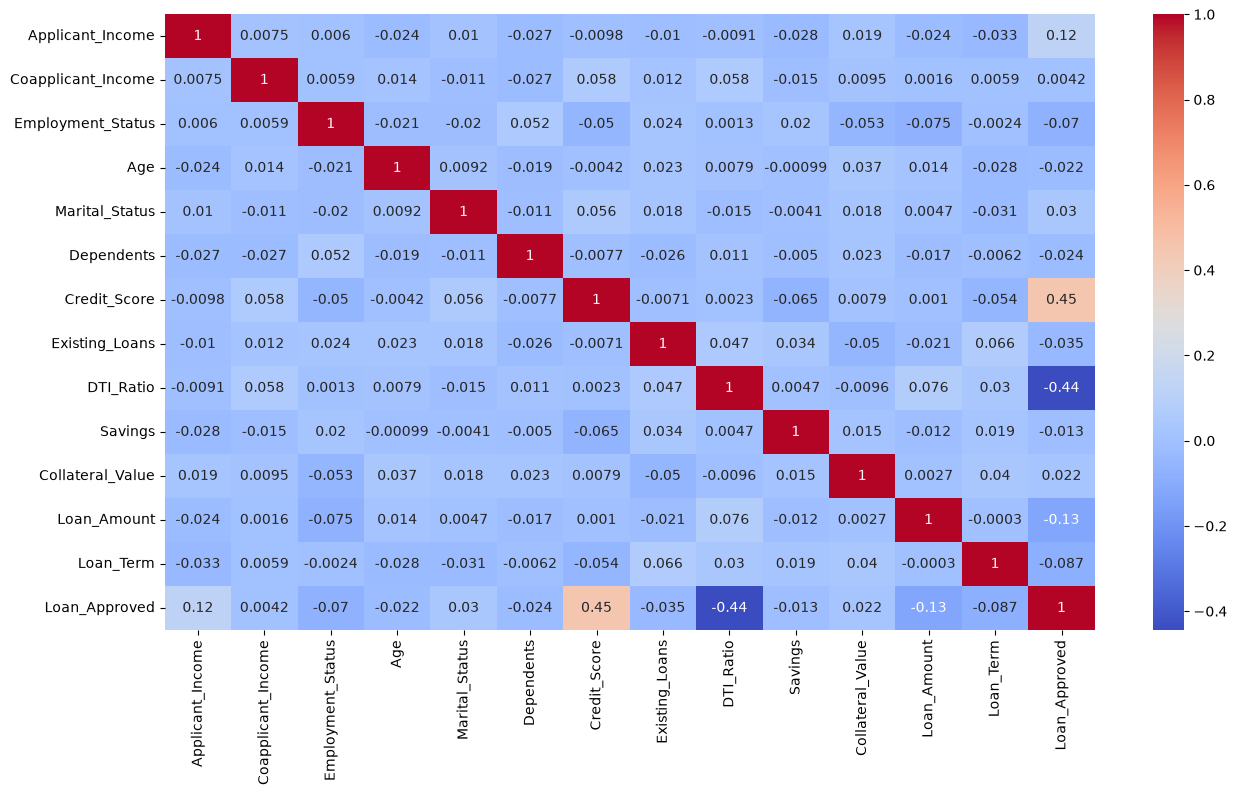

In [37]:
plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrics,
    annot=True,
    cmap="coolwarm"
)

In [ ]:
corr_matrics=num_cols.corr()["Loan_Approved"].sort_values(ascending=False)
corr_matrics